In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#Dataset: https://www.kaggle.com/datasets/danielcorredera/student-mat-csv?select=student-mat.csv


In [3]:
# Load dataset
url = "/content/student-mat.csv"
df = pd.read_csv(url, sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
X = df[['studytime']]
y = df['G3']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Polynomial Regression
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 3.6825493668424505
MSE : 21.806069253762885
RMSE : 4.669696912409079
R2 Score : -0.06344886547630857


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


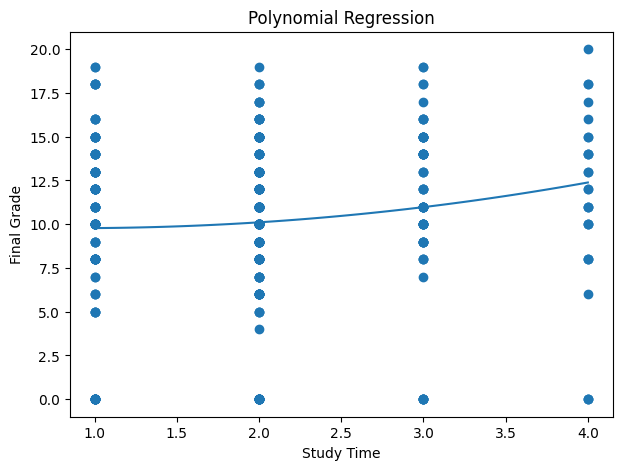

In [5]:
# Polynomial Curve
x_grid = np.linspace(
    X.min().values[0],
    X.max().values[0],
    100
).reshape(-1,1)
plt.figure(figsize=(7,5))
plt.scatter(X, y)
plt.plot(
    x_grid,
    poly_model.predict(x_grid)
)

plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Polynomial Regression")
plt.show()

In [6]:
# Learning Curve - Linear Regression
linear_model = LinearRegression()
train_sizes, train_scores_linear, test_scores_linear = learning_curve(
    linear_model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1,1.0,10),
    scoring='r2'
)

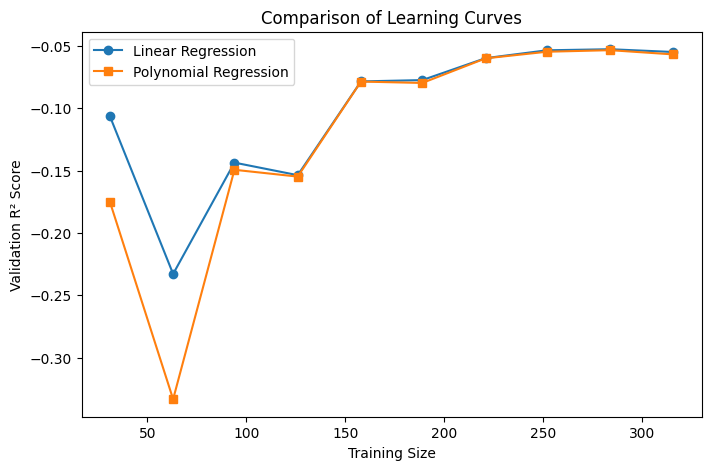

In [7]:
# Learning Curve - Polynomial Regression
train_sizes, train_scores_poly, test_scores_poly = learning_curve(
    poly_model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1,1.0,10),
    scoring='r2'
)
plt.figure(figsize=(8,5))
plt.plot(
    train_sizes,
    test_scores_linear.mean(axis=1),
    marker='o',
    label='Linear Regression'
)
plt.plot(
    train_sizes,
    test_scores_poly.mean(axis=1),
    marker='s',
    label='Polynomial Regression'
)
plt.xlabel("Training Size")
plt.ylabel("Validation R² Score")
plt.title("Comparison of Learning Curves")
plt.legend()
plt.show()